# Two-Stage Multimodal Product Matching System


---

## Executive Summary

This project presents a production-ready solution for **product matching** in e-commerce platforms. A two-stage multimodal pipeline achieves an optimal balance between **speed** and **accuracy**.

Bu proje, e-ticaret platformlarında **ürün eşleştirme (product matching)** problemi için production-ready bir çözüm sunmaktadır. Two-stage multimodal pipeline ile **hız** ve **doğruluk** arasında optimal denge kurulmuştur.

### Key Results
| Metric | Value |
|--------|-------|
| **AUC-ROC** | 0.9533 |
| **F1 Score** | 0.8918 |
| **Recall@1** | 0.9440 (after reranking) |
| **MRR** | 0.9720 |

## Key Takeaways / Temel Çıkarımlar

### Why Two Stages? / Neden İki Aşama?
- **Retrieval** finds *similar* products fast (O(log N)) / *Benzer* ürünleri hızlıca bulur
- **Reranking** decides if they're the *same* product (cross-encoder comparison) / *Aynı* ürün mü karar verir
- Key insight: **Similarity != Identity** — reranker acts as "second pair of eyes" / **Benzerlik != Aynılık**

### Results / Sonuçlar
- Retrieval alone: 94.4% Recall@1
- After reranking: 94.4% Recall@1
- Binary classification: F1 = 0.89, AUC = 0.95

### Production Strategy (Human-in-the-Loop)
Thresholds are **data-driven** (optimized for 95% precision):
- `score >= 0.77` -> **Auto-merge** (model confident it's a match)
- `score < 0.59` -> **Auto-reject** (model confident it's NOT a match)
- `0.59 - 0.77` -> **Human review queue** (uncertain, needs manual verification)
- **~74%** of queries handled automatically, **~26%** routed to human review

### Business Insight / İş Görüşü

**EN:** In production, **false positives are more critical than false negatives**. A wrong merge (FP) corrupts the product catalog and directly harms customer experience (wrong product page, incorrect pricing, misleading reviews). A missed merge (FN) only means a duplicate listing persists, which is less harmful. The 3-zone decision system addresses this by ensuring 95%+ precision in automated decisions and routing uncertain cases to human reviewers.

**TR:** Production'da **false positive'ler false negative'lerden daha kritiktir**. Yanlış birleştirme (FP) ürün kataloğunu bozar ve doğrudan müşteri deneyimini olumsuz etkiler (yanlış ürün sayfası, hatalı fiyatlandırma, yanıltıcı yorumlar). Kaçırılmış birleştirme (FN) ise yalnızca bir duplike listenin devam etmesi anlamına gelir ve daha az zararlıdır. 3 bölgeli karar sistemi, otomatik kararlarda %95+ precision sağlayarak ve belirsiz vakaları insan inceleyicilere yönlendirerek bu sorunu adresler.

## Future Work / Gelecek Çalışma

Error analysis (see `investigation.ipynb`) revealed that many false positives are actually correct predictions penalized by questionable ground truth labels. The model's predictions are sometimes more accurate than the labeled ground truth.

Hata analizi (`investigation.ipynb`'e bakınız) birçok false positive'in aslında söz götürür ground truth etiketleri tarafından cezalandırılan doğru tahminler olduğunu ortaya koymuştur.

### 1. Reranker Prompt Enhancement / Reranker Prompt Güçlendirme
The current instruction focuses only on size/quantity/specification differences. Adding more specific directives would improve discrimination:
- Explicit rejection of different brand/manufacturer products
- Consideration of color, model number, and variant differences
- Incorporating the concept of "visually similar but different product"

### 2. Post-Reranking Verification / Reranking Sonrası Doğrulama
A separate verification step after the reranker's top-1 result:
- A dedicated VLM prompt asking "Are these two products truly the same?"
- Brand, model number, and visual detail comparison
- This would particularly improve precision in the Human-REVIEW zone (0.59-0.77)

### 3. Score Calibration / Skor Kalibrasyonu
Analyzing the FP score distribution to improve the threshold strategy:
- Most FP cases cluster in the 0.65-0.70 range (just above threshold)
- Category-specific thresholds (electronics, clothing, food, etc.) could be explored
- Human-REVIEW zone boundaries can be recalibrated

### 4. Ground Truth Quality / Ground Truth Kalitesi
The ProMapEn dataset has some quality issues where "no match" labels are assigned to products that are visually and semantically near-identical to database entries. Improving dataset quality would yield more reliable metrics.

---

## Problem Statement

Product matching in e-commerce platforms involves identifying identical products from different sellers. This is critical for:
- **Duplicate listing** prevention
- **Product catalog enrichment**
- **Price comparison**
- **Inventory consolidation**

E-ticaret platformlarında **ürün eşleştirme**, farklı satıcılardan gelen aynı ürünlerin tespit edilmesi için kritik bir problemdir.

---

## Two-Stage Pipeline Architecture

```
+-------------------------------------------------------------------------+
|  STAGE 1: RETRIEVAL (Fast - ~0.02s per query)                           |
|  +-- Model: Qwen3-VL-Embedding-2B                                      |
|  +-- Database: ChromaDB (HNSW Index)                                    |
|  +-- Output: Top-K candidates from entire product catalog               |
+-------------------------------------------------------------------------+
|  STAGE 2: RERANKING (Accurate - ~0.5s per query)                        |
|  +-- Model: Qwen3-VL-Reranker-2B (Cross-Encoder)                       |
|  +-- Input: Query + Top-K candidates                                    |
|  +-- Output: Precise match probability [0, 1]                           |
+-------------------------------------------------------------------------+
|  WHY TWO STAGES?                                                        |
|  - Retrieval: O(log N) search through millions of products              |
|  - Reranking: O(K) deep comparison only on top candidates               |
|  - Combined: Best of both worlds - fast AND accurate                    |
+-------------------------------------------------------------------------+
```

---

## Dataset Structure

```
products.csv (Database - 404 products from Walmart)
+-- db_id: Unique identifier
+-- name, description, image, price, source_id

queries.csv (Test queries - 500 total from Amazon)
+-- query_id, name, description, image, price, source_id
+-- has_match: True/False
+-- ground_truth_db_id: Matching product's db_id
```

**Data Source:** ProMapEn Dataset (Amazon vs Walmart product pairs)

## 1. Setup & Configuration / Kurulum ve Yapılandırma

In [1]:
import os
import sys
import gc
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '.')

import torch
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
VRAM: 11.9 GB


In [2]:
class Config:
    """Pipeline configuration for paths, models, and hyperparameters."""
    
    # Paths
    PRODUCTS_CSV = Path("dataset/products.csv")
    QUERIES_CSV = Path("dataset/queries.csv")
    IMAGES_DIR = Path("dataset/images")
    CHROMA_PATH = Path("chroma_db_final_v2")
    
    # Models
    EMBEDDING_MODEL = "Qwen/Qwen3-VL-Embedding-2B"
    RERANKER_MODEL = "Qwen/Qwen3-VL-Reranker-2B"
    
    # Pipeline hyperparameters
    RETRIEVAL_TOP_K = 5   # Number of candidates to retrieve (Recall@5=100%)
    BATCH_SIZE = 10        # Batch size for embedding computation

config = Config()
print("Configuration loaded")

Configuration loaded


## 2. Data Loading / Veri Yükleme

In [3]:
# Load datasets
products_df = pd.read_csv(config.PRODUCTS_CSV)
queries_df = pd.read_csv(config.QUERIES_CSV)

#make df %50 %50 match, no match sample set from n count
n = 500  # Total sample size
queries_df = pd.concat([
    queries_df[queries_df['has_match'] == True].sample(n // 2, random_state=4022026),
    queries_df[queries_df['has_match'] == False].sample(n // 2, random_state=4022026)
]).sample(frac=1, random_state=4022026).reset_index(drop=True)


print("Products (Database):")
print(f"   Total: {len(products_df)}")
print(f"   Columns: {list(products_df.columns)}")

print(f"\nQueries:")
print(f"   Total: {len(queries_df)}")
print(f"   With match: {len(queries_df[queries_df['has_match'] == True])}")
print(f"   Without match: {len(queries_df[queries_df['has_match'] == False])}")

# Verify data integrity
print(f"\nData Integrity Check:")
match_queries = queries_df[queries_df['has_match'] == True]
valid_gt = match_queries['ground_truth_db_id'].isin(products_df['db_id']).sum()
print(f"   Match queries with valid ground_truth_db_id: {valid_gt}/{len(match_queries)}")

Products (Database):
   Total: 404
   Columns: ['db_id', 'name', 'description', 'image', 'price', 'source_id']

Queries:
   Total: 500
   With match: 250
   Without match: 250

Data Integrity Check:
   Match queries with valid ground_truth_db_id: 250/250


In [4]:
# Preview data
print("Sample Products:")
display(products_df.head(3))

print("\nSample Queries (with match):")
display(queries_df[queries_df['has_match'] == True].head(2))

print("\nSample Queries (without match):")
display(queries_df[queries_df['has_match'] == False].head(2))

Sample Products:


,db_id,name,description,image,price,source_id
0,db_0000,Gevi White Espresso Machine 20-Bar New Latte C...,Gevi White Espresso Machine 20-Bar New Latte C...,match_0_db_a957964f70be.jpeg,139.99,https://walmart.com/ip/Gevi-White-Espresso-Mac...
1,db_0001,Motorola Moto G7 Play |Prepaid Smartphone - De...,Motorola Moto G7 Play |Prepaid Smartphone - De...,match_1_db_beebacc00f74.jpeg,NaN,https://walmart.com/ip/Motorola-Moto-G7-Play-P...
2,db_0002,"PEDIGREE Complete Nutrition Chicken, Rice & Ve...","PEDIGREE Complete Nutrition Chicken, Rice & Ve...",match_2_db_97b4aafa33a9.jpeg,NaN,https://walmart.com/ip/PEDIGREE-Complete-Nutri...



Sample Queries (with match):


,query_id,name,description,image,price,source_id,has_match,ground_truth_db_id
0,q_0370_match,NutriChef Automatic Vacuum Air Sealing System ...,NutriChef Automatic Vacuum Air Sealing System ...,match_370_query_429f4907f43e.jpg,59.00,https://www.amazon.com/dp/B01MXLTR09,True,db_0370
3,q_0323_match,[3-Pack] for Samsung Galaxy J3 (2018) Screen P...,[3-Pack] for Samsung Galaxy J3 (2018) Screen P...,match_323_query_9b4f20b758bc.jpg,8.59,https://www.amazon.com/dp/B07KDPGQ93,True,db_0323



Sample Queries (without match):


,query_id,name,description,image,price,source_id,has_match,ground_truth_db_id
1,q_0082_nomatch,JGS1996 Women Scrunch Butt Lifting Seamless Le...,JGS1996 Women Scrunch Butt Lifting Seamless Le...,nomatch_82_query_7e2e6cf3c962.jpg,22.99,https://www.amazon.com/dp/B0819B41CW,False,NaN
2,q_0338_nomatch,"Lenovo Touchscreen 15.6"" IdeaPad Laptop with F...","Lenovo Touchscreen 15.6"" IdeaPad Laptop with F...",nomatch_338_query_c0138b956688.jpg,479.99,https://www.amazon.com/dp/B0B9QBJS28,False,NaN


EXAMPLE: Query WITH match in DB


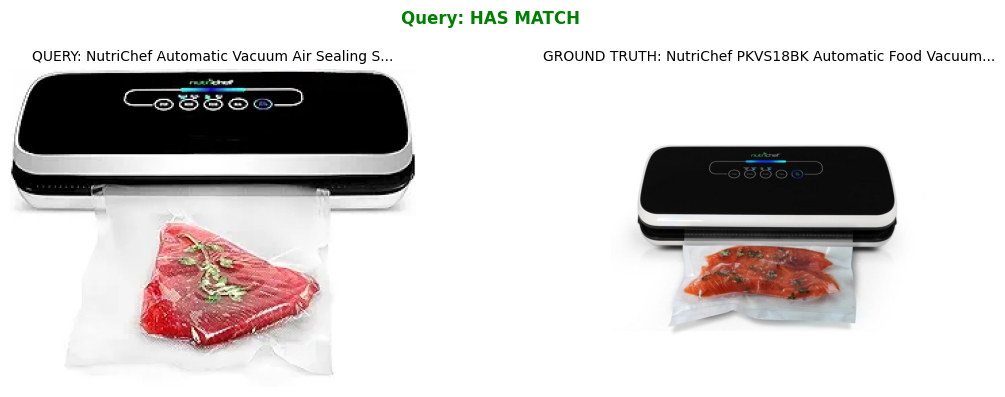


EXAMPLE: Query WITHOUT match in DB


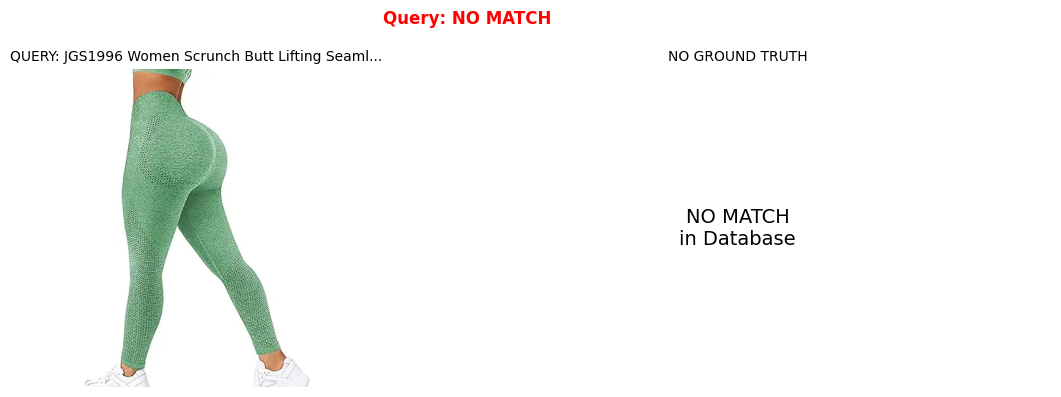

In [5]:
# Visualize sample pairs
from PIL import Image

def show_query_and_match(query_row, products_df, images_dir):
    """Show a query and its ground truth match from DB."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Query
    query_img_path = images_dir / query_row['image']
    if query_img_path.exists():
        axes[0].imshow(Image.open(query_img_path))
    axes[0].set_title(f"QUERY: {query_row['name'][:40]}...", fontsize=10)
    axes[0].axis('off')
    
    # Ground truth from DB
    if query_row['has_match']:
        gt_product = products_df[products_df['db_id'] == query_row['ground_truth_db_id']].iloc[0]
        gt_img_path = images_dir / gt_product['image']
        if gt_img_path.exists():
            axes[1].imshow(Image.open(gt_img_path))
        axes[1].set_title(f"GROUND TRUTH: {gt_product['name'][:40]}...", fontsize=10)
    else:
        axes[1].text(0.5, 0.5, "NO MATCH\nin Database", ha='center', va='center', fontsize=14)
        axes[1].set_title("NO GROUND TRUTH", fontsize=10)
    axes[1].axis('off')
    
    status = "HAS MATCH" if query_row['has_match'] else "NO MATCH"
    color = 'green' if query_row['has_match'] else 'red'
    plt.suptitle(f"Query: {status}", fontsize=12, fontweight='bold', color=color)
    plt.tight_layout()
    plt.show()

# Show examples
print("=" * 60)
print("EXAMPLE: Query WITH match in DB")
print("=" * 60)
match_query = queries_df[queries_df['has_match'] == True].iloc[0]
show_query_and_match(match_query, products_df, config.IMAGES_DIR)

print("\n" + "=" * 60)
print("EXAMPLE: Query WITHOUT match in DB")
print("=" * 60)
nomatch_query = queries_df[queries_df['has_match'] == False].iloc[0]
show_query_and_match(nomatch_query, products_df, config.IMAGES_DIR)

---

## 3. Phase 1: Index Products to ChromaDB / Faz 1: Ürünleri ChromaDB'ye İndeksle

Build the product database by computing multimodal embeddings (text + image) for all products and storing them in ChromaDB with HNSW indexing for fast approximate nearest neighbor search.

Tüm ürünler için multimodal embedding'ler (metin + görsel) hesaplanarak ChromaDB'de HNSW indeksleme ile hızlı yaklaşık en yakın komşu araması için depolanır.

In [6]:
from scripts.qwen3_vl_embedding import Qwen3VLEmbedder

print(f"Loading embedding model: {config.EMBEDDING_MODEL}")

embedder = Qwen3VLEmbedder(
    model_name_or_path=config.EMBEDDING_MODEL,
    torch_dtype=torch.float16
)

print(f"GPU Memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print("Embedding model loaded")

Loading embedding model: Qwen/Qwen3-VL-Embedding-2B


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

GPU Memory: 3.96 GB
Embedding model loaded


In [7]:
import chromadb

client = chromadb.PersistentClient(path=str(config.CHROMA_PATH))

# Clean start
try:
    client.delete_collection(name="products")
    print("Existing collection deleted")
except:
    pass

collection = client.create_collection(
    name="products",
    metadata={"hnsw:space": "cosine"}
)

print(f"ChromaDB initialized: {config.CHROMA_PATH}")

Existing collection deleted
ChromaDB initialized: chroma_db_final_v2


In [8]:
def index_products(products_df, embedder, collection, images_dir, batch_size=10):
    """Index all products into ChromaDB with multimodal embeddings.
    
    For each product, combines text (name + description + extracted json feature list) and image into a 
    single embedding vector using the Qwen3-VL model.
    
    Args:
        products_df: DataFrame with product data (db_id, name, description, image)
        embedder: Qwen3VLEmbedder instance
        collection: ChromaDB collection
        images_dir: Path to product images directory
        batch_size: Number of products to process per batch
    
    Returns:
        Number of successfully indexed products
    """

    print(f"Indexing {len(products_df)} products...")
    
    indexed = 0
    
    for i in tqdm(range(0, len(products_df), batch_size), desc="Indexing"):
        batch = products_df.iloc[i:i+batch_size]
        inputs = []
        ids = []
        docs = []
        metadatas = []
        
        for _, row in batch.iterrows():
            #text = f"{row['name']} {str(row.get('description', ''))[:300]}"
            text = f"""
            product_name: {row['name']}\n
            product_price: {row['price']}\n
            product_desc: {str(row.get('description', ''))[:300]}
            """
            img_path = images_dir / row['image']
            
            if img_path.exists():
                inputs.append({"text": text, "image": str(img_path.absolute())})
            else:
                inputs.append({"text": text})
            print(inputs, "**********\n")
            ids.append(row['db_id'])
            docs.append(text)
            metadatas.append({
                "name": str(row['name']),
                "image": row['image'],
                "price": str(row.get('price', '')),
                "source_id": str(row.get('source_id', ''))
            })
        
        try:
            embeddings = embedder.process(inputs)
            embeddings_list = embeddings.float().cpu().numpy().tolist()
            
            collection.add(
                ids=ids,
                embeddings=embeddings_list,
                documents=docs,
                metadatas=metadatas
            )

            indexed += len(ids)
        except Exception as e:
            print(f"\nError: {e}")
    
    print(f"\nIndexed {indexed} products")
    return indexed

index_products(products_df, embedder, collection, config.IMAGES_DIR, config.BATCH_SIZE)

Indexing 404 products...


Indexing:   0%|          | 0/41 [00:00<?, ?it/s]

[{'text': '\n            product_name: Gevi White Espresso Machine 20-Bar New Latte Cappuccino Maker with Frother, 1.25 L\n\n            product_price: 139.99\n\n            product_desc: Gevi White Espresso Machine 20-Bar New Latte Cappuccino Maker with Frother, 1.25 L | Gevi is a brand from USA which specialized in R&D, design and sales of kitchen and household appliances. Our product covers coffee machine, air fryer, oven, toaster, juicer, electric kettle and many categories, etc.\n            ', 'image': 'c:\\Users\\fkaya\\OneDrive\\Desktop\\product-matching\\dataset\\images\\match_0_db_a957964f70be.jpeg'}] **********

[{'text': '\n            product_name: Gevi White Espresso Machine 20-Bar New Latte Cappuccino Maker with Frother, 1.25 L\n\n            product_price: 139.99\n\n            product_desc: Gevi White Espresso Machine 20-Bar New Latte Cappuccino Maker with Frother, 1.25 L | Gevi is a brand from USA which specialized in R&D, design and sales of kitchen and household app

404

---

## 4. Phase 2: Compute Query Embeddings / Faz 2: Query Embedding'lerini Hesapla

Compute embeddings for all query products using the same model. These will be used to search the ChromaDB index.

Aynı modeli kullanarak tüm query ürünleri için embedding'ler hesapla. Bunlar ChromaDB indeksinde arama yapmak için kullanılacak.

In [9]:
def compute_query_embeddings(queries_df, embedder, images_dir, batch_size=10):
    """Compute multimodal embeddings for all query products.
    
    Args:
        queries_df: DataFrame with query data (name, description, image)
        embedder: Qwen3VLEmbedder instance
        images_dir: Path to query images directory
        batch_size: Number of queries to process per batch
    
    Returns:
        List of embedding vectors (one per query)
    """
    print(f"Computing embeddings for {len(queries_df)} queries...")
    
    all_embeddings = []
    
    for i in tqdm(range(0, len(queries_df), batch_size), desc="Query Embeddings"):
        batch = queries_df.iloc[i:i+batch_size]
        
        inputs = []
        for _, row in batch.iterrows():
            #text = f"{row['name']} {str(row.get('description', ''))[:300]}"
            text = f"""
            product_name: {row['name']}\n
            product_price: {row['price']}\n
            product_desc: {str(row.get('description', ''))[:300]}
            """
            img_path = images_dir / row['image']
            
            if img_path.exists():
                inputs.append({"text": text, "image": str(img_path.absolute())})
            else:
                inputs.append({"text": text})
            print(inputs, "**********\n")
        embeddings = embedder.process(inputs)
        all_embeddings.extend(embeddings.float().cpu().numpy().tolist())
    
    print(f"Computed {len(all_embeddings)} embeddings")
    return all_embeddings

query_embeddings = compute_query_embeddings(queries_df, embedder, config.IMAGES_DIR, config.BATCH_SIZE)

Computing embeddings for 500 queries...


Query Embeddings:   0%|          | 0/50 [00:00<?, ?it/s]

[{'text': '\n            product_name: NutriChef Automatic Vacuum Air Sealing System Preservation with Starter Kit Compact Design, Lab Tested, Dry & Moist Food Modes with Led Indicator Lights, 12", Black\n\n            product_price: 59.0\n\n            product_desc: NutriChef Automatic Vacuum Air Sealing System Preservation with Starter Kit Compact Design, Lab Tested, Dry & Moist Food Modes with Led Indicator Lights, 12", Black | The ideal money and time saving solution: Cooking and meal preparation will become easier, less expensive and faster, as you will be \n            ', 'image': 'c:\\Users\\fkaya\\OneDrive\\Desktop\\product-matching\\dataset\\images\\match_370_query_429f4907f43e.jpg'}] **********

[{'text': '\n            product_name: NutriChef Automatic Vacuum Air Sealing System Preservation with Starter Kit Compact Design, Lab Tested, Dry & Moist Food Modes with Led Indicator Lights, 12", Black\n\n            product_price: 59.0\n\n            product_desc: NutriChef Automat

---

## 5. Phase 3: Retrieval / Faz 3: Aday Getirme

Retrieve the top-K most similar products from ChromaDB for each query using cosine similarity. This is the fast first stage that narrows down the search space.

Her query için ChromaDB'den cosine similarity kullanarak en benzer top-K ürünü getir. Bu, arama alanını daraltan hızlı ilk aşamadır.

In [10]:
def retrieve_candidates(queries_df, query_embeddings, collection, top_k=10):
    """Retrieve top-K candidates for all queries."""
    print(f"Retrieving top-{top_k} candidates for {len(queries_df)} queries...")
    
    all_results = []
    
    for idx, (_, row) in enumerate(tqdm(queries_df.iterrows(), total=len(queries_df), desc="Retrieval")):
        results = collection.query(
            query_embeddings=[query_embeddings[idx]],
            n_results=top_k
        )
        
        candidates = []
        for i in range(len(results['ids'][0])):
            candidates.append({
                'db_id': results['ids'][0][i],
                'text': results['documents'][0][i],
                'metadata': results['metadatas'][0][i],
                'distance': results['distances'][0][i],
                'similarity': 1 - results['distances'][0][i]
            })
        
        all_results.append({
            'query_id': row['query_id'],
            'has_match': row['has_match'],
            'ground_truth_db_id': row['ground_truth_db_id'] if row['has_match'] else None,
            'candidates': candidates
        })
    
    print(f"Retrieved candidates for {len(all_results)} queries")
    return all_results

retrieval_results = retrieve_candidates(queries_df, query_embeddings, collection, config.RETRIEVAL_TOP_K)

Retrieving top-5 candidates for 500 queries...


Retrieval:   0%|          | 0/500 [00:00<?, ?it/s]

Retrieved candidates for 500 queries


In [11]:
# Evaluate retrieval (only for has_match=True queries)
def evaluate_retrieval(results, k_values=[1, 3, 5, 10]):
    """Calculate Recall@K and MRR for queries with matches."""
    match_results = [r for r in results if r['has_match']]
    
    metrics = {}
    
    # Recall@K
    for k in k_values:
        hits = 0
        for r in match_results:
            candidate_ids = [c['db_id'] for c in r['candidates'][:k]]
            if r['ground_truth_db_id'] in candidate_ids:
                hits += 1
        metrics[f'Recall@{k}'] = hits / len(match_results)
    
    # MRR
    reciprocal_ranks = []
    for r in match_results:
        candidate_ids = [c['db_id'] for c in r['candidates']]
        if r['ground_truth_db_id'] in candidate_ids:
            rank = candidate_ids.index(r['ground_truth_db_id']) + 1
            reciprocal_ranks.append(1.0 / rank)
        else:
            reciprocal_ranks.append(0.0)
    metrics['MRR'] = np.mean(reciprocal_ranks)
    
    return metrics

retrieval_metrics = evaluate_retrieval(retrieval_results)

print("\n" + "=" * 50)
print("STAGE 1: RETRIEVAL METRICS")
print("=" * 50)
for metric, value in retrieval_metrics.items():
    print(f"   {metric}: {value:.4f}")
print("=" * 50)


STAGE 1: RETRIEVAL METRICS
   Recall@1: 0.9440
   Recall@3: 0.9960
   Recall@5: 1.0000
   Recall@10: 1.0000
   MRR: 0.9701


In [12]:
# Unload embedder
del embedder
gc.collect()
torch.cuda.empty_cache()

print(f"GPU Memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print("Embedding model unloaded")

GPU Memory: 0.01 GB
Embedding model unloaded


---

## 6. Phase 4: Reranking / Faz 4: Yeniden Sıralama

The cross-encoder reranker takes each (query, candidate) pair and computes a precise match probability. Unlike the bi-encoder which embeds independently, the cross-encoder sees both inputs simultaneously through cross-attention, enabling it to catch subtle differences (pack size, color, model variant).

Cross-encoder reranker, her (query, aday) çiftini alarak kesin bir eşleştirme olasılığı hesaplar. Bağımsız olarak embedding yapan bi-encoder'in aksine, cross-encoder her iki girdiyi de cross-attention aracılığıyla eş zamanlı görür ve ince farklılıkları (paket boyutu, renk, model varyantı) yakalayabilir.

In [13]:
from scripts.qwen3_vl_reranker import Qwen3VLReranker

print(f"Loading reranker model: {config.RERANKER_MODEL}")

reranker = Qwen3VLReranker(
    model_name_or_path=config.RERANKER_MODEL,
    torch_dtype=torch.float16
)

print(f"GPU Memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print("Reranker model loaded")

Loading reranker model: Qwen/Qwen3-VL-Reranker-2B


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

GPU Memory: 3.97 GB
Reranker model loaded


In [14]:
RERANKER_INSTRUCTION = (
    """
    You are a product matching expert for an e-commerce marketplace. Your task is to determine whether two product listings refer to THE EXACT SAME product and can be sold under the same product page.
    
    Scoring Rules:

    Return a score between 0.0 and 1.0:
    - 0.9 - 1.0: Exact same product. Same brand, model, size, color, quantity, condition.
    - 0.7 - 0.89: Very likely the same product with only trivial differences (e.g. slightly different title wording, minor photo difference).
    - 0.4 - 0.69: Similar product but at least one uncertain attribute — needs caution.
    - 0.1 - 0.39: Clearly different in at least one critical attribute (different size, color, pack count, model variant, condition).
    - 0.0 - 0.09: Completely different products.

    Critical Attributes to Compare:

    You MUST pay close attention to the following (a mismatch in ANY should significantly lower the score):
    1. Brand & Model
    2. Size / Capacity / Volume
    3. Color / Variant
    4. Pack Size / Quantity
    5. Condition
    6. Price Consistency (if prices differ dramatically without clear justification)
    7. Model Year / Version / Generation
    8. Flavor / Scent / Material
    9. Accessories / Bundled Items
    10. Target Region / Voltage / Plug Type

    How to Think:
    - When in doubt, score LOW. False merges are worse than false separations.
    - Do NOT assume missing information means a match; treat uncertain attributes with caution.
    - One critical attribute mismatch (size, brand, model, pack count, color, etc) = NOT a match.
    - Generic/unbranded products should only match if ALL visible attributes align.
    """
)

def rerank_all(queries_df, retrieval_results, reranker, images_dir):
    """Rerank retrieval candidates using cross-encoder for precise matching.
    
    For each query, the top-5 candidates from retrieval (Recall@5=100%) are
    scored by the cross-encoder which jointly encodes query-candidate pairs.
    
    Args:
        queries_df: DataFrame with query data
        retrieval_results: List of retrieval result dicts with candidates
        reranker: Qwen3VLReranker instance
        images_dir: Path to images directory
    
    Returns:
        List of result dicts with reranked candidates and best_score
    """
    print(f"Reranking candidates for {len(retrieval_results)} queries...")
    
    all_reranked = []
    
    for idx, r in enumerate(tqdm(retrieval_results, desc="Reranking")):
        query_row = queries_df.iloc[idx]
        # Recall@5 = 100%, so we only need top-5 candidates for reranking
        candidates = r['candidates'][:5]
        
        if not candidates:
            all_reranked.append({**r, 'reranked': [], 'best_score': 0.0})
            continue
        
        # Prepare query
        query_text = f"{query_row['name']} {str(query_row.get('description', ''))[:300]}"
        query_img_path = images_dir / query_row['image']
        
        query = {"text": query_text}
        if query_img_path.exists():
            query['image'] = str(query_img_path.absolute())
        
        # Prepare documents
        documents = []
        for cand in candidates:
            doc = {"text": cand['text']}
            img_path = images_dir / cand['metadata'].get('image', '')
            if img_path.exists():
                doc['image'] = str(img_path.absolute())
            documents.append(doc)
        
        # Rerank
        scores = reranker.process({
            "instruction": RERANKER_INSTRUCTION,
            "query": query,
            "documents": documents
        })
        
        # Combine and sort by rerank score
        reranked = []
        for cand, score in zip(candidates, scores):
            reranked.append({**cand, 'rerank_score': score})
        reranked.sort(key=lambda x: x['rerank_score'], reverse=True)
        
        all_reranked.append({
            **r,
            'reranked': reranked,
            'best_score': reranked[0]['rerank_score'] if reranked else 0.0
        })
    
    print(f"Reranked {len(all_reranked)} queries")
    return all_reranked

reranked_results = rerank_all(queries_df, retrieval_results, reranker, config.IMAGES_DIR)

Reranking candidates for 500 queries...


Reranking:   0%|          | 0/500 [00:00<?, ?it/s]

Reranked 500 queries


In [15]:
# Unload reranker
del reranker
gc.collect()
torch.cuda.empty_cache()

print(f"GPU Memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print("Reranker model unloaded")

GPU Memory: 0.01 GB
Reranker model unloaded


In [33]:
# Save or load reranked_results depending on existence

import pickle
import os

reranked_results_path = "reranked_results.pkl"

# If reranked_results already computed, save it; otherwise, try to load it
if reranked_results is not None:
    with open(reranked_results_path, "wb") as f:
        pickle.dump(reranked_results, f)
    print("reranked_results saved to reranked_results.pkl")
else:
    if os.path.exists(reranked_results_path):
        with open(reranked_results_path, "rb") as f:
            reranked_results = pickle.load(f)
        print("reranked_results loaded from reranked_results.pkl")
    else:
        raise FileNotFoundError("reranked_results is None and reranked_results.pkl not found.")

reranked_results saved to reranked_results.pkl


---

## 7. Phase 5: Evaluation / Faz 5: Degerlendirme

Comprehensive evaluation including:
- **Retrieval metrics:** Recall@K and MRR before/after reranking
- **Binary classification:** Threshold optimization, Precision, Recall, F1, AUC-ROC
- **Production thresholds:** 3-zone decision system (Auto-Merge / Human-Review / Auto-Reject)

Kapsamli degerlendirme:
- **Retrieval metrikleri:** Reranking oncesi/sonrasi Recall@K ve MRR
- **Binary siniflandirma:** Threshold optimizasyonu, Precision, Recall, F1, AUC-ROC
- **Production threshold'lari:** 3 bolge karar sistemi (Otomatik-Birlestir / Insan-Kontrol / Otomatik-Red)

In [34]:
# Evaluate reranking (Recall@K after rerank)
def evaluate_reranking(results, k_values=[1, 3, 5]):
    """Calculate Recall@K and MRR after reranking."""
    match_results = [r for r in results if r['has_match']]
    
    metrics = {}
    
    for k in k_values:
        hits = 0
        for r in match_results:
            candidate_ids = [c['db_id'] for c in r['reranked'][:k]]
            if r['ground_truth_db_id'] in candidate_ids:
                hits += 1
        metrics[f'Rerank_Recall@{k}'] = hits / len(match_results)
    
    # MRR after rerank
    reciprocal_ranks = []
    for r in match_results:
        candidate_ids = [c['db_id'] for c in r['reranked']]
        if r['ground_truth_db_id'] in candidate_ids:
            rank = candidate_ids.index(r['ground_truth_db_id']) + 1
            reciprocal_ranks.append(1.0 / rank)
        else:
            reciprocal_ranks.append(0.0)
    metrics['Rerank_MRR'] = np.mean(reciprocal_ranks)
    
    return metrics

rerank_metrics = evaluate_reranking(reranked_results)

print("\n" + "=" * 50)
print("STAGE 2: RERANKING METRICS (Match Queries)")
print("=" * 50)
for metric, value in rerank_metrics.items():
    print(f"   {metric}: {value:.4f}")
print("=" * 50)


STAGE 2: RERANKING METRICS (Match Queries)
   Rerank_Recall@1: 0.9440
   Rerank_Recall@3: 1.0000
   Rerank_Recall@5: 1.0000
   Rerank_MRR: 0.9720


In [35]:
# Compare retrieval vs reranking
print("\nRETRIEVAL vs RERANKING COMPARISON")
print("=" * 50)
print(f"{'Metric':<20} {'Retrieval':<12} {'Reranking':<12} {'Delta':<10}")
print("-" * 50)

for k in [1, 3, 5]:
    ret_val = retrieval_metrics.get(f'Recall@{k}', 0)
    rerank_val = rerank_metrics.get(f'Rerank_Recall@{k}', 0)
    delta = rerank_val - ret_val
    print(f"Recall@{k:<14} {ret_val:<12.4f} {rerank_val:<12.4f} {delta:+.4f}")

ret_mrr = retrieval_metrics.get('MRR', 0)
rerank_mrr = rerank_metrics.get('Rerank_MRR', 0)
print(f"{'MRR':<20} {ret_mrr:<12.4f} {rerank_mrr:<12.4f} {rerank_mrr - ret_mrr:+.4f}")
print("=" * 50)


RETRIEVAL vs RERANKING COMPARISON
Metric               Retrieval    Reranking    Delta     
--------------------------------------------------
Recall@1              0.9440       0.9440       +0.0000
Recall@3              0.9960       1.0000       +0.0040
Recall@5              1.0000       1.0000       +0.0000
MRR                  0.9701       0.9720       +0.0019


In [36]:
# Threshold optimization for binary classification
scores = [r['best_score'] for r in reranked_results]
labels = [1 if r['has_match'] else 0 for r in reranked_results]

# Extract top2 scores and margins for margin-based decision layer
top2_scores = []
margins = []
for r in reranked_results:
    t2 = r['reranked'][1]['rerank_score'] if len(r['reranked']) > 1 else 0.0
    top2_scores.append(t2)
    margins.append(r['best_score'] - t2)

print(f"\nScore Distribution:")
match_scores = [s for s, l in zip(scores, labels) if l == 1]
nomatch_scores = [s for s, l in zip(scores, labels) if l == 0]
print(f"   Match scores: min={min(match_scores):.3f}, max={max(match_scores):.3f}, mean={np.mean(match_scores):.3f}")
print(f"   No-match scores: min={min(nomatch_scores):.3f}, max={max(nomatch_scores):.3f}, mean={np.mean(nomatch_scores):.3f}")

print(f"\nMargin Distribution (top1 - top2):")
match_margins = [m for m, l in zip(margins, labels) if l == 1]
nomatch_margins = [m for m, l in zip(margins, labels) if l == 0]
print(f"   Match margins: min={min(match_margins):.3f}, max={max(match_margins):.3f}, mean={np.mean(match_margins):.3f}")
print(f"   No-match margins: min={min(nomatch_margins):.3f}, max={max(nomatch_margins):.3f}, mean={np.mean(nomatch_margins):.3f}")


Score Distribution:
   Match scores: min=0.390, max=0.883, mean=0.776
   No-match scores: min=0.097, max=0.857, mean=0.431

Margin Distribution (top1 - top2):
   Match margins: min=0.001, max=0.790, mean=0.444
   No-match margins: min=0.000, max=0.612, mean=0.152


In [37]:
def find_optimal_threshold(scores, labels):
    """Find threshold that maximizes F1."""
    thresholds = np.arange(0.05, 0.95, 0.02)
    results = []
    
    for thresh in thresholds:
        preds = [1 if s >= thresh else 0 for s in scores]
        
        precision = precision_score(labels, preds, zero_division=0)
        recall = recall_score(labels, preds, zero_division=0)
        f1 = f1_score(labels, preds, zero_division=0)
        
        results.append({
            'threshold': thresh,
            'precision': precision,
            'recall': recall,
            'f1': f1
        })
    
    best = max(results, key=lambda x: x['f1'])
    return best, results

best_thresh, thresh_results = find_optimal_threshold(scores, labels)

# AUC-ROC
auc = roc_auc_score(labels, scores)

print("\n" + "=" * 60)
print("THRESHOLD OPTIMIZATION (Binary Classification)")
print("=" * 60)
print(f"Optimal Threshold: {best_thresh['threshold']:.2f}")
print(f"Precision: {best_thresh['precision']:.4f}")
print(f"Recall:    {best_thresh['recall']:.4f}")
print(f"F1 Score:  {best_thresh['f1']:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print("=" * 60)


THRESHOLD OPTIMIZATION (Binary Classification)
Optimal Threshold: 0.65
Precision: 0.8484
Recall:    0.9400
F1 Score:  0.8918
AUC-ROC:   0.9533


In [38]:
# Margin-Enhanced Decision Analysis (abs_threshold + margin_threshold)
# This adds a "confidence gap" check: is the top-1 score clearly ahead of top-2?

def find_optimal_with_margin(scores, margins, labels, abs_threshold):
    """Find best margin threshold that maximizes F1, given a fixed absolute threshold."""
    best = {'margin_thresh': 0.0, 'precision': 0, 'recall': 0, 'f1': 0}
    
    for mt in np.arange(0.00, 0.30, 0.01):
        preds = [1 if s >= abs_threshold and m >= mt else 0
                 for s, m in zip(scores, margins)]
        p = precision_score(labels, preds, zero_division=0)
        r = recall_score(labels, preds, zero_division=0)
        f = f1_score(labels, preds, zero_division=0)
        
        if f > best['f1']:
            best = {'margin_thresh': round(mt, 2), 'precision': p, 'recall': r, 'f1': f}
    
    return best

abs_thresh_val = best_thresh['threshold']
best_margin = find_optimal_with_margin(scores, margins, labels, abs_thresh_val)

print("=" * 60)
print("MARGIN-ENHANCED THRESHOLD OPTIMIZATION")
print("=" * 60)
print(f"\nAbsolute Threshold: {abs_thresh_val:.2f}")
print(f"Optimal Margin Threshold: {best_margin['margin_thresh']:.2f}")
print(f"\n{'Metric':<15} {'Abs Only':<15} {'Abs + Margin':<15} {'Delta':<10}")
print("-" * 55)
print(f"{'Precision':<15} {best_thresh['precision']:<15.4f} {best_margin['precision']:<15.4f} {best_margin['precision'] - best_thresh['precision']:+.4f}")
print(f"{'Recall':<15} {best_thresh['recall']:<15.4f} {best_margin['recall']:<15.4f} {best_margin['recall'] - best_thresh['recall']:+.4f}")
print(f"{'F1 Score':<15} {best_thresh['f1']:<15.4f} {best_margin['f1']:<15.4f} {best_margin['f1'] - best_thresh['f1']:+.4f}")
print("=" * 60)

MARGIN_THRESHOLD = best_margin['margin_thresh']

MARGIN-ENHANCED THRESHOLD OPTIMIZATION

Absolute Threshold: 0.65
Optimal Margin Threshold: 0.00

Metric          Abs Only        Abs + Margin    Delta     
-------------------------------------------------------
Precision       0.8484          0.8484          +0.0000
Recall          0.9400          0.9400          +0.0000
F1 Score        0.8918          0.8918          +0.0000


In [39]:
# Production Thresholds: 3-Zone Decision System (Human-in-the-Loop)
TARGET_PRECISION = 0.95

def find_production_thresholds(scores, labels, target_precision=TARGET_PRECISION):
    """Find thresholds for 3-zone production decision system.
    
    Zones:
        - Score >= upper_threshold -> Auto-merge (high precision positive predictions)
        - Score <  lower_threshold -> Auto-reject (high precision negative predictions)
        - Between -> Human review queue
    
    Args:
        scores: Model scores (0-1 range)
        labels: Ground truth labels (0 or 1)
        target_precision: Target precision for automated decisions (default: 0.95)
    
    Returns:
        tuple: (upper_threshold, lower_threshold)
    """
    scores = np.array(scores)
    labels = np.array(labels)
    
    # Upper threshold: minimum threshold where precision >= target
    upper_threshold = None
    for thresh in np.arange(0.30, 0.96, 0.01):
        preds = (scores >= thresh).astype(int)
        if preds.sum() > 0:
            prec = precision_score(labels, preds, zero_division=0)
            if prec >= target_precision:
                upper_threshold = thresh
                break
    
    # Lower threshold: maximum threshold where negative precision >= target
    lower_threshold = None
    for thresh in np.arange(0.70, 0.04, -0.01):
        below_thresh = scores < thresh
        if below_thresh.sum() > 0:
            true_negatives = ((scores < thresh) & (labels == 0)).sum()
            predicted_negatives = below_thresh.sum()
            neg_precision = true_negatives / predicted_negatives
            if neg_precision >= target_precision:
                lower_threshold = thresh
                break
    
    return upper_threshold, lower_threshold

upper_thresh, lower_thresh = find_production_thresholds(scores, labels)

# Calculate zone statistics (with margin-enhanced auto-merge)
scores_arr = np.array(scores)
labels_arr = np.array(labels)
margins_arr = np.array(margins)

# Auto-merge now requires BOTH: score >= upper_thresh AND margin >= MARGIN_THRESHOLD
auto_merge = sum(1 for s, m in zip(scores, margins) if s >= upper_thresh and m >= MARGIN_THRESHOLD) if upper_thresh else 0
auto_reject = sum(1 for s in scores if s < lower_thresh) if lower_thresh else 0
human_review = len(scores) - auto_merge - auto_reject

merge_correct = ((scores_arr >= upper_thresh) & (margins_arr >= MARGIN_THRESHOLD) & (labels_arr == 1)).sum() if upper_thresh else 0
reject_correct = ((scores_arr < lower_thresh) & (labels_arr == 0)).sum() if lower_thresh else 0

print("=" * 70)
print("PRODUCTION THRESHOLDS (Human-in-the-Loop + Margin)")
print("=" * 70)
print(f"\nTarget: {int(TARGET_PRECISION * 100)}% precision in automated decisions")
print(f"Margin Threshold: {MARGIN_THRESHOLD:.2f} (top1 - top2 score gap)\n")
print(f"{'Zone':<20} {'Condition':<30} {'Count':<10} {'Accuracy':<10}")
print("-" * 70)
print(f"{'Auto-MERGE':<20} {'score>=' + f'{upper_thresh:.2f} & margin>={MARGIN_THRESHOLD:.2f}':<30} {auto_merge:<10} {merge_correct/max(auto_merge,1)*100:.1f}%")
print(f"{'Human REVIEW':<20} {'otherwise':<30} {human_review:<10} {'N/A':<10}")
print(f"{'Auto-REJECT':<20} {'score < ' + f'{lower_thresh:.2f}':<30} {auto_reject:<10} {reject_correct/max(auto_reject,1)*100:.1f}%")
print("-" * 70)
print(f"\nAutomation Rate: {(auto_merge + auto_reject) / len(scores) * 100:.1f}% of queries handled automatically")
print(f"Human Review Rate: {human_review / len(scores) * 100:.1f}% of queries need human review")
print("=" * 70)

PRODUCTION THRESHOLDS (Human-in-the-Loop + Margin)

Target: 95% precision in automated decisions
Margin Threshold: 0.00 (top1 - top2 score gap)

Zone                 Condition                      Count      Accuracy  
----------------------------------------------------------------------
Auto-MERGE           score>=0.77 & margin>=0.00     169        95.9%
Human REVIEW         otherwise                      130        N/A       
Auto-REJECT          score < 0.59                   201        95.5%
----------------------------------------------------------------------

Automation Rate: 74.0% of queries handled automatically
Human Review Rate: 26.0% of queries need human review


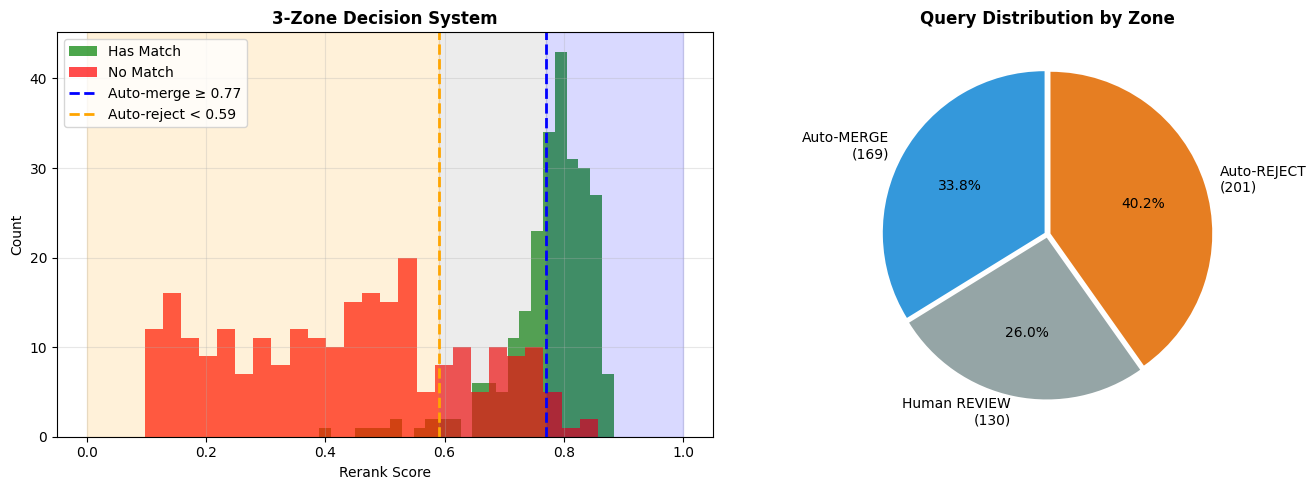

In [40]:
# Visualize 3-zone decision system
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Score distribution with 3 zones
ax1 = axes[0]
ax1.hist(match_scores, bins=25, alpha=0.7, label='Has Match', color='green')
ax1.hist(nomatch_scores, bins=25, alpha=0.7, label='No Match', color='red')

# Zone boundaries
ax1.axvline(upper_thresh, color='blue', linestyle='--', linewidth=2, label=f'Auto-merge ≥ {upper_thresh:.2f}')
ax1.axvline(lower_thresh, color='orange', linestyle='--', linewidth=2, label=f'Auto-reject < {lower_thresh:.2f}')

# Shade zones
ax1.axvspan(upper_thresh, 1.0, alpha=0.15, color='blue', label='_nolegend_')
ax1.axvspan(0, lower_thresh, alpha=0.15, color='orange', label='_nolegend_')
ax1.axvspan(lower_thresh, upper_thresh, alpha=0.15, color='gray', label='_nolegend_')

ax1.set_xlabel('Rerank Score')
ax1.set_ylabel('Count')
ax1.set_title('3-Zone Decision System', fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Zone breakdown pie chart
ax2 = axes[1]
zone_counts = [auto_merge, human_review, auto_reject]
zone_labels = [f'Auto-MERGE\n({auto_merge})', f'Human REVIEW\n({human_review})', f'Auto-REJECT\n({auto_reject})']
zone_colors = ['#3498db', '#95a5a6', '#e67e22']
explode = (0.02, 0.02, 0.02)

wedges, texts, autotexts = ax2.pie(zone_counts, labels=zone_labels, colors=zone_colors, 
                                    explode=explode, autopct='%1.1f%%', startangle=90,
                                    textprops={'fontsize': 10})
ax2.set_title('Query Distribution by Zone', fontweight='bold')

plt.tight_layout()
plt.savefig('figs/production_thresholds.png', dpi=150)
plt.show()

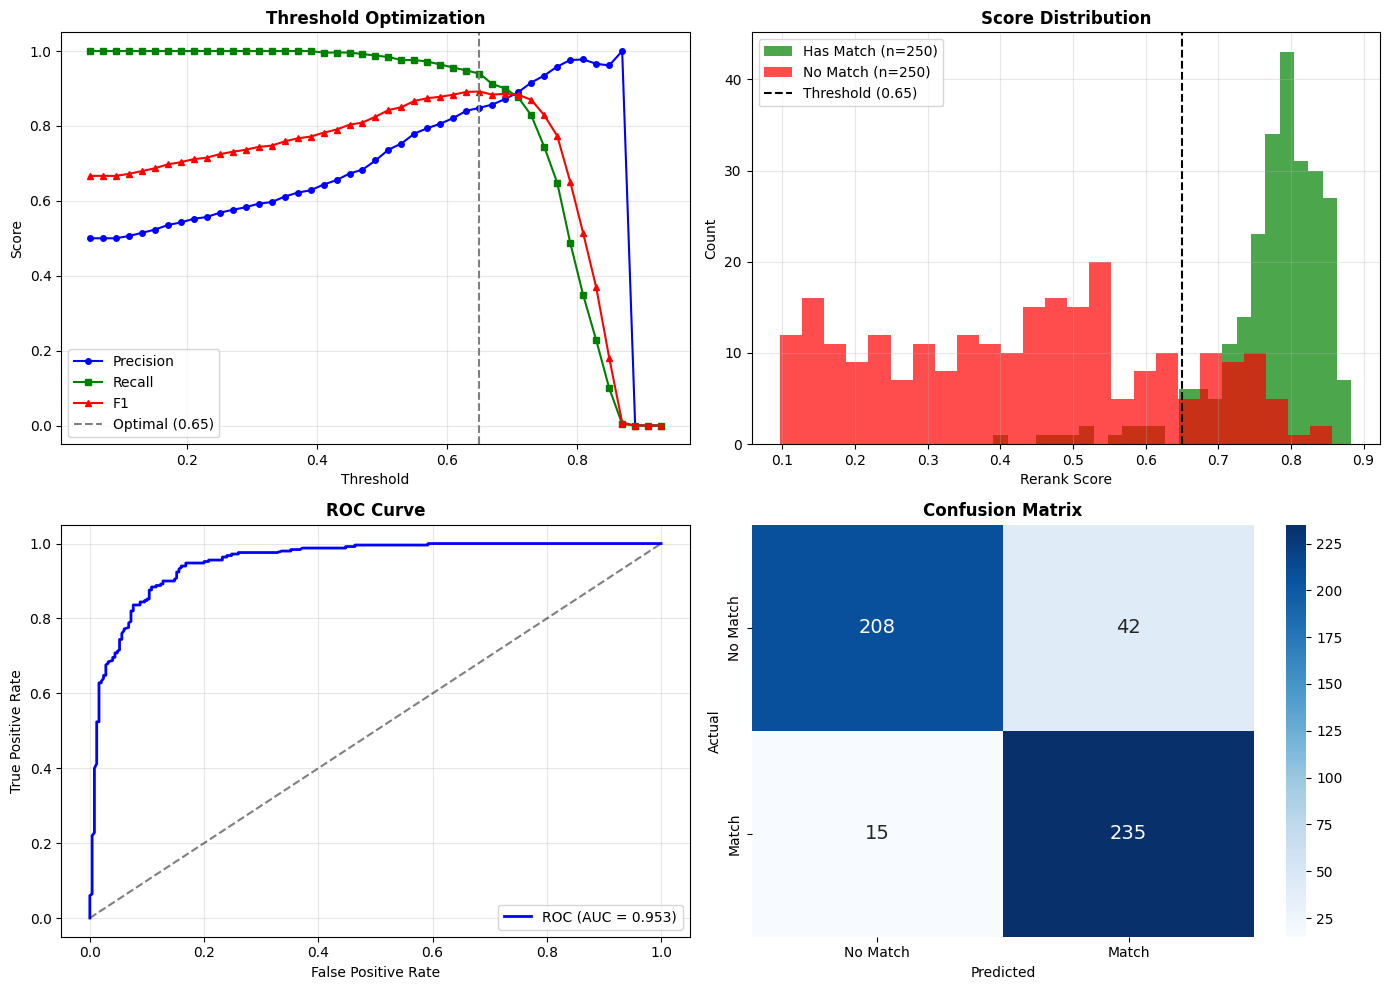

In [41]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Threshold optimization
ax1 = axes[0, 0]
df_thresh = pd.DataFrame(thresh_results)
ax1.plot(df_thresh['threshold'], df_thresh['precision'], 'b-o', label='Precision', markersize=4)
ax1.plot(df_thresh['threshold'], df_thresh['recall'], 'g-s', label='Recall', markersize=4)
ax1.plot(df_thresh['threshold'], df_thresh['f1'], 'r-^', label='F1', markersize=5)
ax1.axvline(x=best_thresh['threshold'], color='gray', linestyle='--', label=f'Optimal ({best_thresh["threshold"]:.2f})')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Threshold Optimization', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Score distribution
ax2 = axes[0, 1]
ax2.hist(match_scores, bins=25, alpha=0.7, label=f'Has Match (n={len(match_scores)})', color='green')
ax2.hist(nomatch_scores, bins=25, alpha=0.7, label=f'No Match (n={len(nomatch_scores)})', color='red')
ax2.axvline(x=best_thresh['threshold'], color='black', linestyle='--', label=f'Threshold ({best_thresh["threshold"]:.2f})')
ax2.set_xlabel('Rerank Score')
ax2.set_ylabel('Count')
ax2.set_title('Score Distribution', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. ROC Curve
ax3 = axes[1, 0]
fpr, tpr, _ = roc_curve(labels, scores)
ax3.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.3f})')
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Confusion Matrix
ax4 = axes[1, 1]
preds = [1 if s >= best_thresh['threshold'] else 0 for s in scores]
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Match', 'Match'],
            yticklabels=['No Match', 'Match'], ax=ax4, annot_kws={'size': 14})
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')
ax4.set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('figs/evaluation_results_v2.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 8. Demo: Pipeline in Action / Demo: Pipeline Çalışması

Demonstrate the complete pipeline flow for individual queries — showing how a product goes through retrieval, reranking, and final decision.

Bireysel query'ler için tam pipeline akışını göster — bir ürünün retrieval, reranking ve son karar aşamalarından nasıl geçtiğini gösteriyoruz.

In [42]:
PRODUCTION_THRESHOLD = best_thresh['threshold']

def demo_query(idx, results, queries_df, products_df, threshold, margin_threshold=0.0):
    """Demo the pipeline decision for a query (with margin check)."""
    r = results[idx]
    query_row = queries_df.iloc[idx]
    
    # Calculate margin
    top1_score = r['best_score']
    top2_score = r['reranked'][1]['rerank_score'] if len(r['reranked']) > 1 else 0.0
    margin = top1_score - top2_score
    
    print("\n" + "=" * 70)
    print("PRODUCT MATCHING DEMO")
    print("=" * 70)
    
    print(f"\nQuery: {query_row['name'][:60]}...")
    print(f"   Has match in DB: {r['has_match']}")
    if r['has_match']:
        print(f"   Ground truth: {r['ground_truth_db_id']}")
    
    print(f"\nPipeline Result:")
    print(f"   Top-1 score: {top1_score:.4f}  (threshold: {threshold:.2f})")
    print(f"   Top-2 score: {top2_score:.4f}")
    print(f"   Margin:      {margin:.4f}  (threshold: {margin_threshold:.2f})")
    
    abs_match = top1_score >= threshold
    margin_ok = margin >= margin_threshold
    predicted_match = abs_match and margin_ok
    
    if predicted_match:
        best = r['reranked'][0]
        print(f"\n   PREDICTION: MATCH FOUND (abs={abs_match}, margin_ok={margin_ok})")
        print(f"   Matched: {best['metadata']['name'][:50]}... (score: {best['rerank_score']:.3f})")
    else:
        reason = []
        if not abs_match:
            reason.append("score below threshold")
        if not margin_ok:
            reason.append("margin too small")
        print(f"\n   PREDICTION: NO MATCH ({', '.join(reason)})")
    
    # Check correctness
    if r['has_match']:
        found_correct = r['reranked'][0]['db_id'] == r['ground_truth_db_id'] if r['reranked'] else False
        correct = predicted_match and found_correct
    else:
        correct = not predicted_match
    
    print(f"\nGround Truth: {'HAS MATCH' if r['has_match'] else 'NO MATCH'}")
    print(f"   Result: {'CORRECT' if correct else 'INCORRECT'}")
    
    print("\n" + "-" * 70)
    print("Top-3 Candidates:")
    for i, cand in enumerate(r['reranked'][:3]):
        marker = "[GT]" if cand['db_id'] == r.get('ground_truth_db_id') else "    "
        print(f"   {marker} {i+1}. [{cand['rerank_score']:.3f}] {cand['metadata']['name'][:45]}...")
    print("=" * 70)

In [43]:
# Demo: Query with match
match_idx = queries_df[queries_df['has_match'] == True].index[0]
demo_query(match_idx, reranked_results, queries_df, products_df, PRODUCTION_THRESHOLD, MARGIN_THRESHOLD)


PRODUCT MATCHING DEMO

Query: NutriChef Automatic Vacuum Air Sealing System Preservation w...
   Has match in DB: True
   Ground truth: db_0370

Pipeline Result:
   Top-1 score: 0.7192  (threshold: 0.65)
   Top-2 score: 0.2001
   Margin:      0.5192  (threshold: 0.00)

   PREDICTION: MATCH FOUND (abs=True, margin_ok=True)
   Matched: NutriChef PKVS18BK Automatic Food Vacuum Sealer... (score: 0.719)

Ground Truth: HAS MATCH
   Result: CORRECT

----------------------------------------------------------------------
Top-3 Candidates:
   [GT] 1. [0.719] NutriChef PKVS18BK Automatic Food Vacuum Seal...
        2. [0.200] FoodSaver Easy Seal & Peel 8" x 18' Vacuum Se...
        3. [0.147] Ultrean Air Fryer 5.8 Quart, Toaster Oven Oil...


In [44]:
# Demo: Query without match
nomatch_idx = queries_df[queries_df['has_match'] == False].index[1]
demo_query(nomatch_idx, reranked_results, queries_df, products_df, PRODUCTION_THRESHOLD, MARGIN_THRESHOLD)


PRODUCT MATCHING DEMO

Query: Lenovo Touchscreen 15.6" IdeaPad Laptop with Fingerprint Rea...
   Has match in DB: False

Pipeline Result:
   Top-1 score: 0.3643  (threshold: 0.65)
   Top-2 score: 0.2832
   Margin:      0.0811  (threshold: 0.00)

   PREDICTION: NO MATCH (score below threshold)

Ground Truth: NO MATCH
   Result: CORRECT

----------------------------------------------------------------------
Top-3 Candidates:
        1. [0.364] Restored LENOVO 81WE0016US IdeaPad 3 15IIL05 ...
        2. [0.283] Microsoft Surface Laptop 3, 13.5" Touch-Scree...
        3. [0.267] Lenovo IdeaPad 3 17", Intel Core i5-1035G1, 8...


---

## 9. Final Summary / Son Ozet

In [45]:
print("\n" + "=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)

print(f"\nDataset:")
print(f"   Products in DB: {len(products_df)}")
print(f"   Total queries: {len(queries_df)}")
print(f"   - With match: {len(queries_df[queries_df['has_match'] == True])}")
print(f"   - Without match: {len(queries_df[queries_df['has_match'] == False])}")

print(f"\nStage 1 - Retrieval:")
for metric, value in retrieval_metrics.items():
    print(f"   {metric}: {value:.4f}")

print(f"\nStage 2 - Reranking:")
for metric, value in rerank_metrics.items():
    print(f"   {metric}: {value:.4f}")

print(f"\nBinary Classification (Absolute Threshold Only):")
print(f"   Threshold: {best_thresh['threshold']:.2f}")
print(f"   Precision: {best_thresh['precision']:.4f}")
print(f"   Recall: {best_thresh['recall']:.4f}")
print(f"   F1 Score: {best_thresh['f1']:.4f}")
print(f"   AUC-ROC: {auc:.4f}")

print(f"\nBinary Classification (Absolute + Margin Threshold):")
print(f"   Abs Threshold: {best_thresh['threshold']:.2f}")
print(f"   Margin Threshold: {MARGIN_THRESHOLD:.2f}")
print(f"   Precision: {best_margin['precision']:.4f}")
print(f"   Recall: {best_margin['recall']:.4f}")
print(f"   F1 Score: {best_margin['f1']:.4f}")

print(f"\nProduction Strategy (Human-in-the-Loop + Margin):")
print(f"   Auto-merge: score >= {upper_thresh:.2f} AND margin >= {MARGIN_THRESHOLD:.2f}")
print(f"   Auto-reject: score < {lower_thresh:.2f}")
print(f"   Human review: otherwise")

print("\n" + "=" * 70)


FINAL RESULTS SUMMARY

Dataset:
   Products in DB: 404
   Total queries: 500
   - With match: 250
   - Without match: 250

Stage 1 - Retrieval:
   Recall@1: 0.9440
   Recall@3: 0.9960
   Recall@5: 1.0000
   Recall@10: 1.0000
   MRR: 0.9701

Stage 2 - Reranking:
   Rerank_Recall@1: 0.9440
   Rerank_Recall@3: 1.0000
   Rerank_Recall@5: 1.0000
   Rerank_MRR: 0.9720

Binary Classification (Absolute Threshold Only):
   Threshold: 0.65
   Precision: 0.8484
   Recall: 0.9400
   F1 Score: 0.8918
   AUC-ROC: 0.9533

Binary Classification (Absolute + Margin Threshold):
   Abs Threshold: 0.65
   Margin Threshold: 0.00
   Precision: 0.8484
   Recall: 0.9400
   F1 Score: 0.8918

Production Strategy (Human-in-the-Loop + Margin):
   Auto-merge: score >= 0.77 AND margin >= 0.00
   Auto-reject: score < 0.59
   Human review: otherwise



---

## 10. Export Results to Excel (with Images) / Sonuclari Excel'e Aktar (Gorsellerle)

In [46]:
# Export comprehensive results to Excel with images
from scripts.export_results_to_excel import create_excel_report, prepare_results_dataframe

# Prepare results DataFrame (with decision zones)
results_df = prepare_results_dataframe(
    reranked_results,
    threshold=best_thresh['threshold'],
    upper_threshold=upper_thresh,
    lower_threshold=lower_thresh
)

# Prepare metrics dictionary
all_metrics = {
    'retrieval': retrieval_metrics,
    'reranking': rerank_metrics,
    'classification': {
        'Threshold': best_thresh['threshold'],
        'Precision': best_thresh['precision'],
        'Recall': best_thresh['recall'],
        'F1_Score': best_thresh['f1'],
        'AUC_ROC': auc
    },
    'production_thresholds': {
        'Upper_Threshold (Auto-Merge)': upper_thresh,
        'Lower_Threshold (Auto-Reject)': lower_thresh,
        'Target_Precision': 0.95
    }
}

# Create Excel report (with images - might take a minute)
print("Creating Excel report with embedded images...")
print("This may take a few minutes...")

excel_path = create_excel_report(
    results_df=results_df,
    products_df=products_df,
    queries_df=queries_df,
    metrics=all_metrics,
    output_path=Path("results.xlsx"),
    include_images=True
)

print(f"\n✅ Excel report created: {excel_path}")

Creating Excel report with embedded images...
This may take a few minutes...
Excel report saved to: results.xlsx

✅ Excel report created: results.xlsx


In [47]:
# Preview results DataFrame
print("Results Preview (first 10 rows):")
display(results_df[['query_id', 'has_match', 'best_score', 'decision_zone', 'status', 'is_correct']].head(10))

# Summary statistics
print("\nResult Statistics:")
print(f"   Total queries: {len(results_df)}")
print(f"   Correct predictions: {results_df['is_correct'].sum()} ({100*results_df['is_correct'].mean():.1f}%)")

print("\n   Status breakdown:")
display(results_df['status'].value_counts())

print("\n   Decision Zone breakdown:")
display(results_df['decision_zone'].value_counts())

Results Preview (first 10 rows):


,query_id,has_match,best_score,decision_zone,status,is_correct
0,q_0370_match,True,0.719238,Human-REVIEW,TP,True
1,q_0082_nomatch,False,0.722168,Human-REVIEW,FP,False
2,q_0338_nomatch,False,0.364258,Auto-REJECT,TN,True
3,q_0323_match,True,0.741211,Human-REVIEW,TP,True
4,q_0359_nomatch,False,0.324707,Auto-REJECT,TN,True
5,q_0295_nomatch,False,0.405518,Auto-REJECT,TN,True
6,q_0211_nomatch,False,0.192505,Auto-REJECT,TN,True
7,q_0094_match,True,0.839844,Auto-MERGE,FN,False
8,q_0254_nomatch,False,0.545898,Auto-REJECT,TN,True
9,q_0120_match,True,0.816406,Auto-MERGE,TP,True



Result Statistics:
   Total queries: 500
   Correct predictions: 430 (86.0%)

   Status breakdown:


status
TP    222
TN    208
FP     42
FN     28
Name: count, dtype: int64


   Decision Zone breakdown:


decision_zone
Auto-REJECT     201
Auto-MERGE      169
Human-REVIEW    130
Name: count, dtype: int64

---

## 11. Visual Results Grid (Sample Predictions) / Gorsel Sonuc Tablosu (Ornek Tahminler)

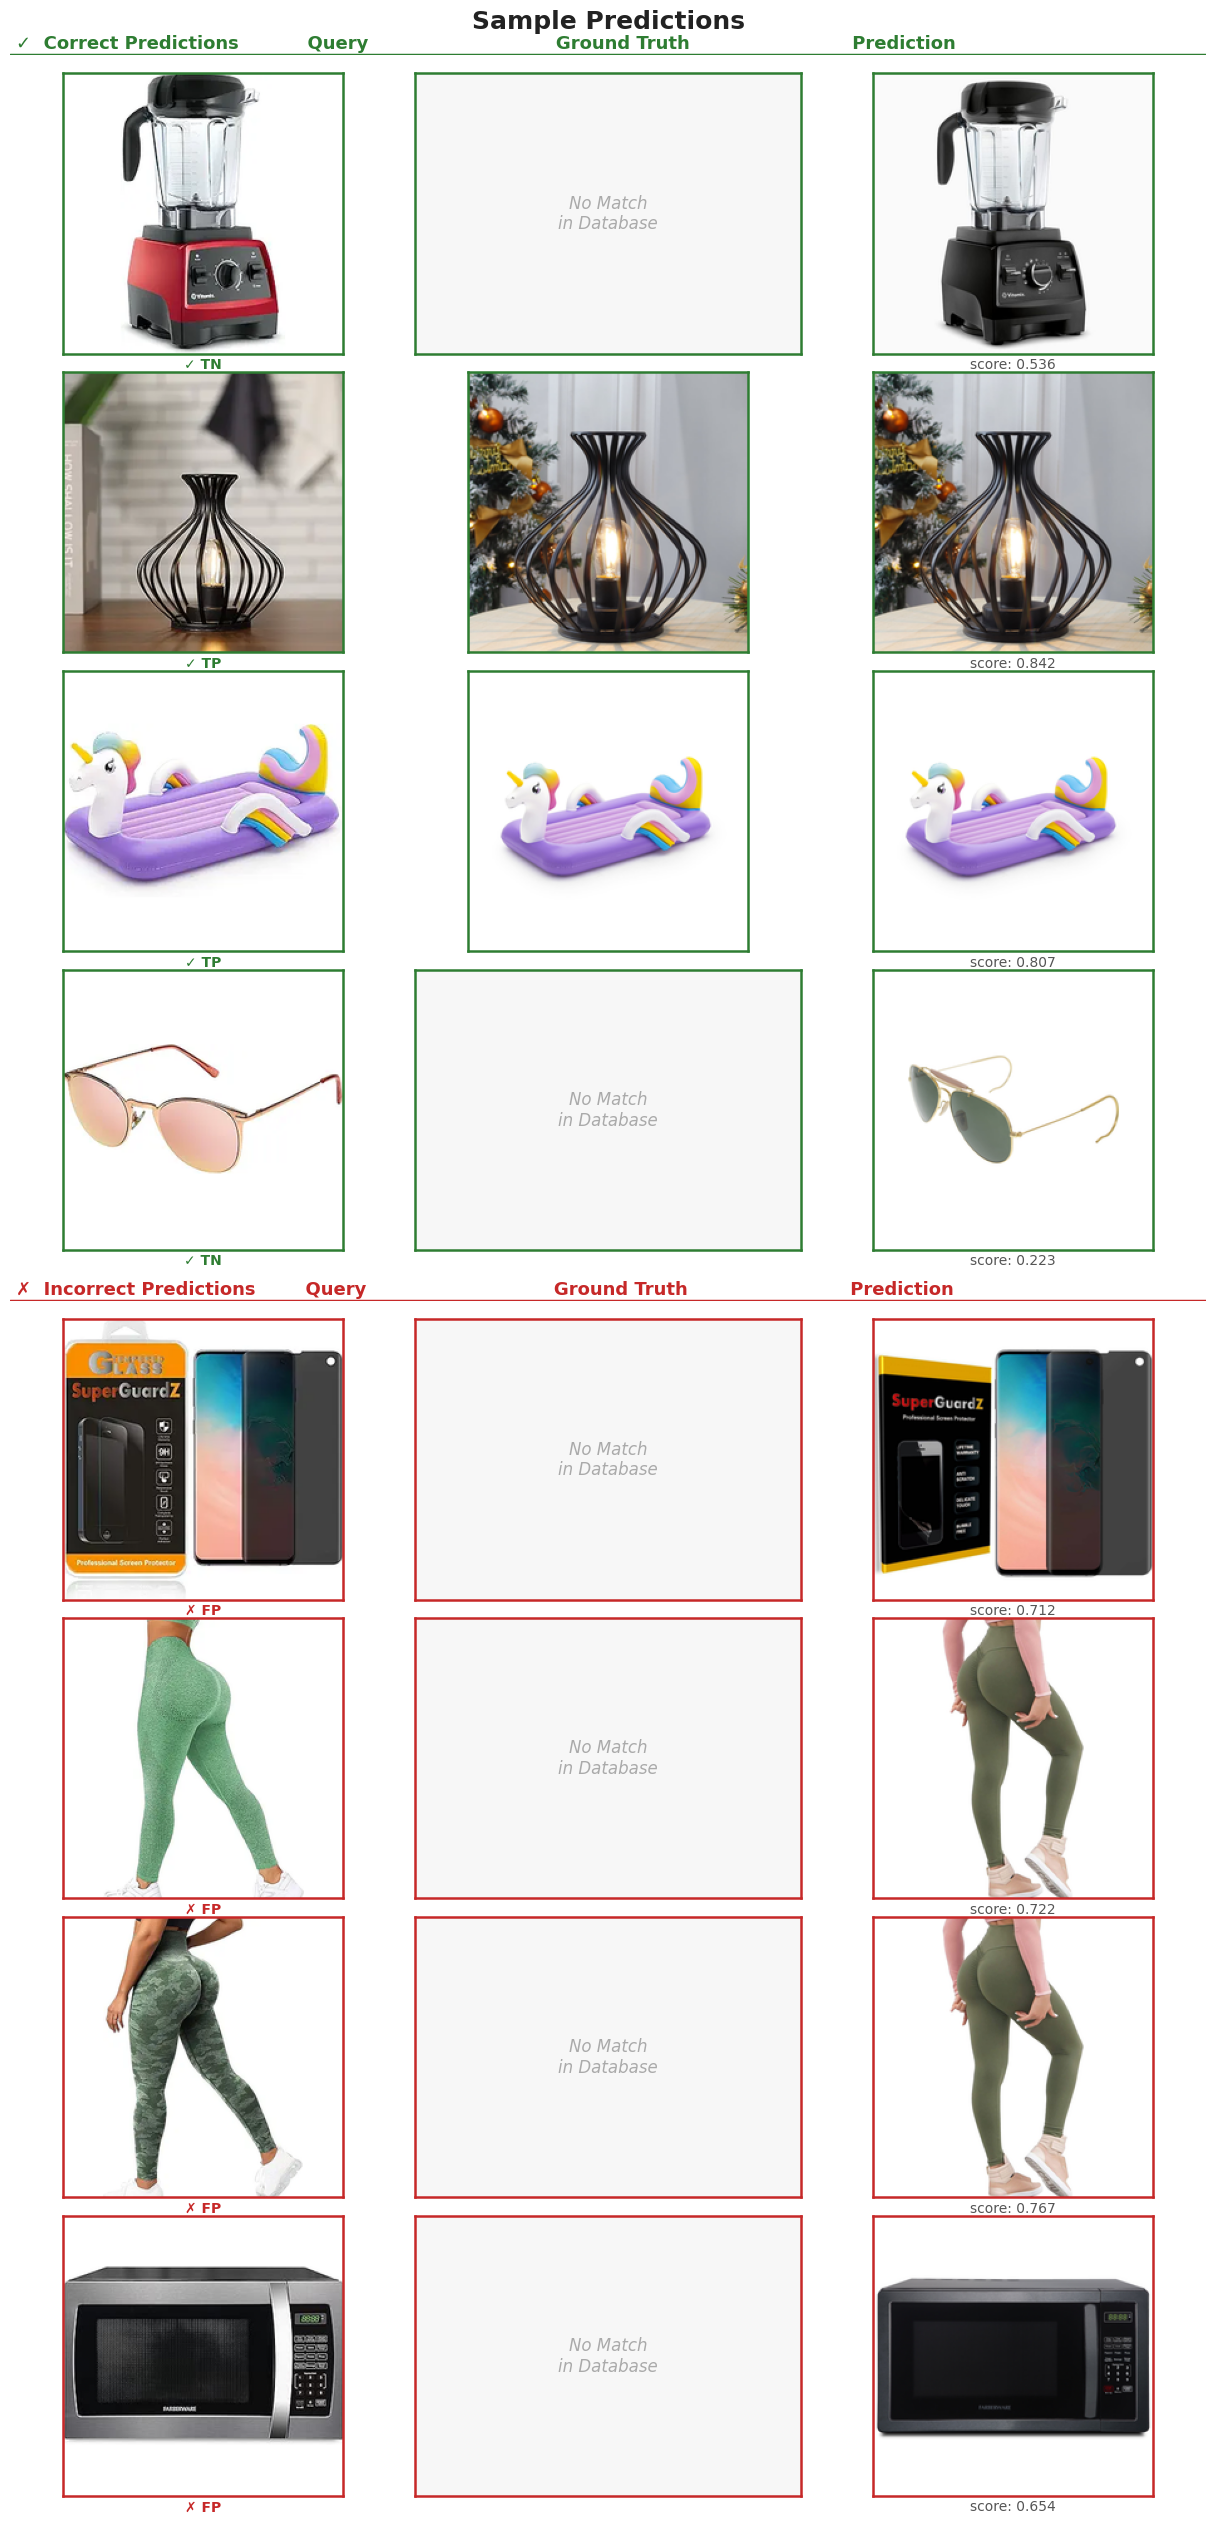

In [67]:
# Sample predictions grid: 4 correct + 4 incorrect
from PIL import Image
import numpy as np

correct_samples = results_df[results_df['is_correct'] == True].sample(4, random_state=42)
incorrect_samples = results_df[results_df['is_correct'] == False].sample(4, random_state=42)
samples = pd.concat([correct_samples, incorrect_samples])

def load_and_pad(img_path, target_size=224):
    """Load image, resize to fit target_size while keeping aspect ratio, pad to square."""
    img = Image.open(img_path).convert('RGB')
    img.thumbnail((target_size, target_size), Image.LANCZOS)
    padded = Image.new('RGB', (target_size, target_size), (255, 255, 255))
    x_off = (target_size - img.width) // 2
    y_off = (target_size - img.height) // 2
    padded.paste(img, (x_off, y_off))
    return np.array(padded)

IMG_SIZE = 224
N_CORRECT = len(correct_samples)
N_INCORRECT = len(incorrect_samples)
N_TOTAL = N_CORRECT + N_INCORRECT

import matplotlib.gridspec as gridspec

# Layout rows: [correct_header, 4x correct, incorrect_header, 4x incorrect]
# Heights: section_header=0.3, image_row=3.0
SEC_H, ROW_H = 0.35, 3.0
n_rows = 2 + N_TOTAL  # 2 section headers + 8 image rows
h_ratios = [SEC_H] + [ROW_H]*N_CORRECT + [SEC_H] + [ROW_H]*N_INCORRECT

fig = plt.figure(figsize=(13, sum(h_ratios) + 0.8), facecolor='white')
gs = gridspec.GridSpec(n_rows, 3, figure=fig, height_ratios=h_ratios,
                       hspace=0.08, wspace=0.05,
                       left=0.04, right=0.96, top=0.975, bottom=0.005)

# --- Section header helper ---
def draw_section_header(grid_row, text, color):
    ax = fig.add_subplot(gs[grid_row, :])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axhline(0.0, color=color, linewidth=2.5, solid_capstyle='round')
    ax.text(0.005, 0.35, text, fontsize=13, fontweight='bold', color=color,
            va='center', transform=ax.transAxes)
    ax.axis('off')

draw_section_header(0, '✓  Correct Predictions           Query                              Ground Truth                          Prediction', '#2e7d32')
draw_section_header(1 + N_CORRECT, '✗  Incorrect Predictions        Query                              Ground Truth                          Prediction', '#c62828')

# --- Draw one image row ---
def draw_row(grid_row, row_data, qrow_data):
    is_correct = row_data['is_correct']
    border_c = '#2e7d32' if is_correct else '#c62828'
    bg_c = '#f1f8f1' if is_correct else '#fdf0f0'
    symbol = '✓' if is_correct else '✗'

    imgs = [None, None, None]
    gt_placeholder = False

    qp = config.IMAGES_DIR / qrow_data['image']
    if qp.exists(): imgs[0] = load_and_pad(qp, IMG_SIZE)

    if row_data['has_match']:
        gt = products_df[products_df['db_id'] == row_data['ground_truth_db_id']].iloc[0]
        gp = config.IMAGES_DIR / gt['image']
        if gp.exists(): imgs[1] = load_and_pad(gp, IMG_SIZE)
    else:
        gt_placeholder = True

    if row_data['top1_db_id']:
        pr = products_df[products_df['db_id'] == row_data['top1_db_id']].iloc[0]
        pp = config.IMAGES_DIR / pr['image']
        if pp.exists(): imgs[2] = load_and_pad(pp, IMG_SIZE)

    for c in range(3):
        ax = fig.add_subplot(gs[grid_row, c])
        ax.set_facecolor(bg_c)

        if imgs[c] is not None:
            ax.imshow(imgs[c])
        elif c == 1 and gt_placeholder:
            ax.text(0.5, 0.5, 'No Match\nin Database', ha='center', va='center',
                    fontsize=12, color='#aaaaaa', fontstyle='italic',
                    transform=ax.transAxes)
            ax.set_facecolor('#f7f7f7')

        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_edgecolor(border_c); sp.set_linewidth(1.8)

        # Bottom label: status under query, score under prediction
        if c == 0:
            ax.set_xlabel(f'{symbol} {row_data["status"]}', fontsize=10,
                          fontweight='bold', color=border_c, labelpad=3)
        elif c == 2:
            ax.set_xlabel(f'score: {row_data["best_score"]:.3f}', fontsize=10,
                          color='#555555', labelpad=3)

# --- Correct rows (grid rows 1..4) ---
sample_list = list(samples.iterrows())
for i in range(N_CORRECT):
    _, row = sample_list[i]
    qrow = queries_df[queries_df['query_id'] == row['query_id']].iloc[0]
    draw_row(1 + i, row, qrow)

# --- Incorrect rows (grid rows 6..9) ---
for i in range(N_INCORRECT):
    _, row = sample_list[N_CORRECT + i]
    qrow = queries_df[queries_df['query_id'] == row['query_id']].iloc[0]
    draw_row(2 + N_CORRECT + i, row, qrow)

fig.suptitle('Sample Predictions', fontsize=18, fontweight='bold', color='#222222')

plt.savefig('figs/predictions_grid.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

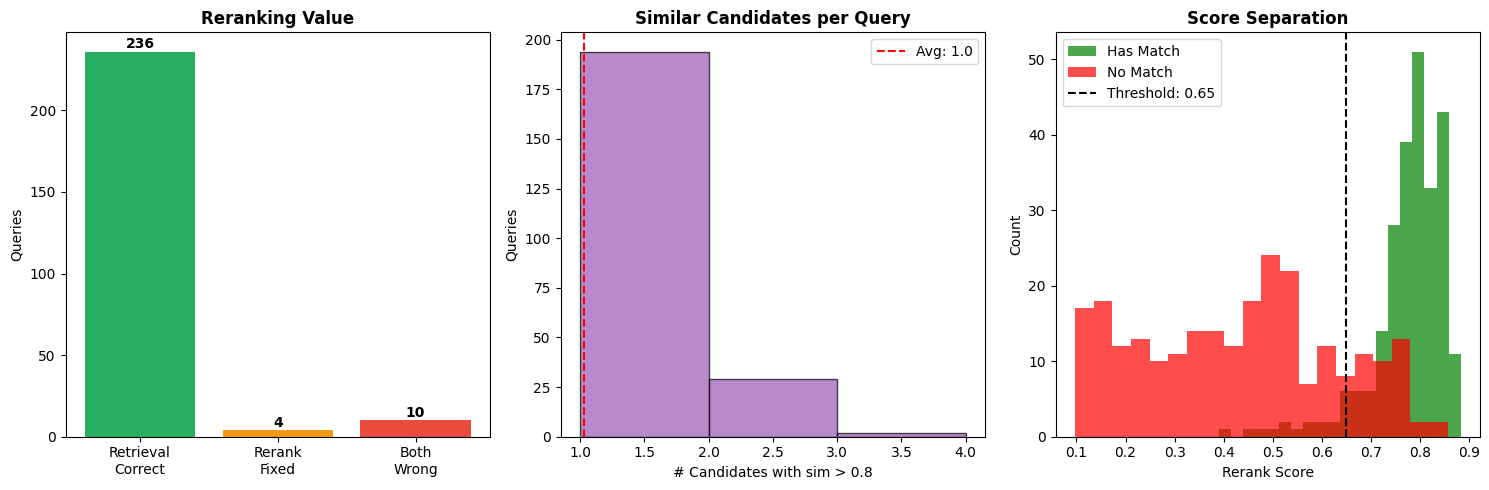

In [49]:
# Why reranking matters - visual analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

match_results = [r for r in reranked_results if r['has_match']]

# 1. Reranking fixes retrieval mistakes
retrieval_correct = sum(1 for r in match_results if r['candidates'][0]['db_id'] == r['ground_truth_db_id'])
rerank_fixed = sum(1 for r in match_results if r['candidates'][0]['db_id'] != r['ground_truth_db_id'] 
                   and r['reranked'][0]['db_id'] == r['ground_truth_db_id'])
both_wrong = len(match_results) - retrieval_correct - rerank_fixed

bars = axes[0].bar(['Retrieval\nCorrect', 'Rerank\nFixed', 'Both\nWrong'], 
                   [retrieval_correct, rerank_fixed, both_wrong],
                   color=['#27ae60', '#f39c12', '#e74c3c'])
axes[0].set_ylabel('Queries')
axes[0].set_title('Reranking Value', fontweight='bold')
for bar, val in zip(bars, [retrieval_correct, rerank_fixed, both_wrong]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), ha='center', fontweight='bold')

# 2. Multiple similar candidates problem
close_counts = [sum(1 for c in r['candidates'] if c['similarity'] > 0.8) for r in match_results]
axes[1].hist(close_counts, bins=range(1, max(close_counts)+2), color='#9b59b6', alpha=0.7, edgecolor='black')
axes[1].axvline(np.mean(close_counts), color='red', linestyle='--', label=f'Avg: {np.mean(close_counts):.1f}')
axes[1].set_xlabel('# Candidates with sim > 0.8')
axes[1].set_ylabel('Queries')
axes[1].set_title('Similar Candidates per Query', fontweight='bold')
axes[1].legend()

# 3. Score separation
axes[2].hist(match_scores, bins=20, alpha=0.7, label='Has Match', color='green')
axes[2].hist(nomatch_scores, bins=20, alpha=0.7, label='No Match', color='red')
axes[2].axvline(best_thresh['threshold'], color='black', linestyle='--', label=f'Threshold: {best_thresh["threshold"]:.2f}')
axes[2].set_xlabel('Rerank Score')
axes[2].set_ylabel('Count')
axes[2].set_title('Score Separation', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('figs/reranking_analysis.png', dpi=150)
plt.show()

---

## 12. Final Summary / Son Ozet

In [50]:
# Summary table
summary_data = {
    'Stage': ['Retrieval', 'Retrieval', 'Reranking', 'Reranking', 'Classification', 'Classification', 'Classification'],
    'Metric': ['Recall@1', 'MRR', 'Recall@1', 'MRR', 'Precision', 'Recall', 'F1'],
    'Value': [
        retrieval_metrics['Recall@1'],
        retrieval_metrics['MRR'],
        rerank_metrics['Rerank_Recall@1'],
        rerank_metrics['Rerank_MRR'],
        best_thresh['precision'],
        best_thresh['recall'],
        best_thresh['f1']
    ]
}
summary_df = pd.DataFrame(summary_data)
summary_df['Value'] = summary_df['Value'].apply(lambda x: f"{x:.4f}")

display(summary_df.pivot(index='Metric', columns='Stage', values='Value'))

Stage,Classification,Reranking,Retrieval
Metric,,,
F1,0.8918,NaN,NaN
MRR,NaN,0.9720,0.9701
Precision,0.8484,NaN,NaN
Recall,0.9400,NaN,NaN
Recall@1,NaN,0.9440,0.9440


---

## References 

- [Qwen3-VL-Embedding-2B](https://huggingface.co/Qwen/Qwen3-VL-Embedding-2B) - Multimodal embedding model
- [Qwen3-VL-Reranker-2B](https://huggingface.co/Qwen/Qwen3-VL-Reranker-2B) - Cross-encoder reranker model
- [ChromaDB](https://docs.trychroma.com/) - Vector database with HNSW indexing
- [ProMapEn Dataset](https://github.com/kackamac/Product-Mapping-Datasets) - Amazon vs Walmart product pairs